In [2]:
# Step 1: Import Required Libraries
library(readr)       # For reading CSV files efficiently
library(dplyr)       # For data manipulation
library(ggplot2)     # For visualizations
library(tidyr)       # For tidying data
library(corrplot)    # For correlation plots
library(moments)     # For skewness and kurtosis

# Step 2: Load and Explore the Data
# 2a. Load the data
data <- read_csv("C:/Users/sharo/OneDrive/Desktop/LSE Data Course/3rd Assignment/LSE_DA301_assignment_files_new/turtle_reviews.csv")

# Check for missing values
print("Missing Values in Each Column:")
print(colSums(is.na(data)))

# View the head of the data
head(data)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang
corrplot 0.95 loaded
Parsed with column specification:
cols(
  gender = col_character(),
  age = col_double(),
  `remuneration (k£)` = col_double(),
  `spending_score (1-100)` = col_double(),
  loyalty_points = col_double(),
  education = col_character(),
  language = col_character(),
  platform = col_character(),
  product = col_double(),
  review = col_character(),
  summary = col_character()
)


[1] "Missing Values in Each Column:"
                gender                    age      remuneration (k£) 
                     0                      0                      0 
spending_score (1-100)         loyalty_points              education 
                     0                      0                      0 
              language               platform                product 
                     0                      0                      0 
                review                summary 
                     0                      0 


gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on the screen itself is at an absolute premium. The fact that 50% of this space is wasted on art (and not terribly informative or needed art as well) makes it completely useless. The only reason that I gave it 2 stars and not 1 was that, technically speaking, it can at least still stand up to block your notes and dice rolls. Other than that, it drops the ball completely.",The fact that 50% of this space is wasted on art (and not terribly informative or needed art ...
Male,23,12.30,81,524,graduate,EN,Web,466,"An Open Letter to GaleForce9*: Your unpainted miniatures are very not bad. Your spell cards are great. Your board games are ""meh"". Your DM screens, however, are freaking terrible. I'm still waiting for a single screen that isn't polluted with pointless artwork where useful, reference-able tables should be. Once again, you've created a single use screen that is only useful when running the ""Storm King's Thunder"" adventure. Even despite the fact that it's geared to that adventure path, it's usefulness negligible, at best. I massive swath of the inner panel is wasted on artwork and a bloated overland map, which could have been easily reduced to a single panel in size. And the few table you have are nigh-useless themselves. In short, stop making crap DM screens.",Another worthless Dungeon Master's screen from GaleForce9
Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are filled with a general Forgotten Realms map is beyond me. Most of one of them is all blue ocean. Such a waste. I don't understand why they can't make these DM Screens more useful for these ""kinds of adventures"" rather than solely the specific adventure. You're supposed to be able to transpose this adventure to other lands outside the Forgotten Realms. So even just a list of new monsters or NPCs would at least be useful than the map. Even more would just be stuff related to running the game but broad-use stuff related to giants. Same thing with Curse of Strahd. Why not make it useful for raven loft, undead or horror campaigns in general... instead a huge amount of screen space is solely mapping out Castle Ravenloft, which is only useful during a small fraction of the time even for the Curse of Strahd adventure, let alone various other Ravenloft adventuring. They really kill the extended use of these screens by not thinking about their potential use, both for the adventure in question, as well as use in a broader sense. The Rage of Demons screen is far more useful for broad under dark adventuring - covering a lot of rules for the various conditions you may suffer... and the map is only one panel. This Storm Giants one is decent for a few tables it includes - but really misses the mark. Maybe they should ask a few DMs what they would use?","pretty, but also pretty useless"
Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new dm and it's perfect!,Five Stars
Female,33,13.94,40,366,graduate,EN,Web,291,"As my review of GF9's previous screens these were completely unnecessary and nearly useless. Skip them, this is the definition of a waste of money.",Money trap
Female,24,13.94,76,573,PhD,EN,Web,977,Grandson loves,Five Stars


In [4]:
# 2b. Create a summary of the data frame
print("Summary of Data:")
summary(data)

# Check factor levels for categorical variables
print("Gender Levels:")
print(levels(data$gender))
print("Education Levels:")
print(levels(data$education))

[1] "Summary of Data:"


    gender               age        remuneration (k£) spending_score (1-100)
 Length:2000        Min.   :17.00   Min.   : 12.30    Min.   : 1            
 Class :character   1st Qu.:29.00   1st Qu.: 30.34    1st Qu.:32            
 Mode  :character   Median :38.00   Median : 47.15    Median :50            
                    Mean   :39.49   Mean   : 48.08    Mean   :50            
                    3rd Qu.:49.00   3rd Qu.: 63.96    3rd Qu.:73            
                    Max.   :72.00   Max.   :112.34    Max.   :99            
 loyalty_points  education           language           platform        
 Min.   :  25   Length:2000        Length:2000        Length:2000       
 1st Qu.: 772   Class :character   Class :character   Class :character  
 Median :1276   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1578                                                           
 3rd Qu.:1751                                                           
 Max.   :6847          

[1] "Gender Levels:"
NULL
[1] "Education Levels:"
NULL


In [6]:
# 2c. Basic Data Cleaning
# - Rename columns for clarity: remuneration (k£) to remuneration, spending_score (1-100) to spending_score
# - Drop 'product' column as it's not needed
# - Convert character columns to factors for categorical analysis
data <- data %>%
  rename(remuneration = `remuneration (k£)`, spending_score = `spending_score (1-100)`) %>%
  select(-product) %>%
  mutate_if(is.character, as.factor)

# Verify column classes after cleaning
print("Column Classes After Cleaning:")
print(sapply(data, class))

[1] "Column Classes After Cleaning:"
        gender            age   remuneration spending_score loyalty_points 
      "factor"      "numeric"      "numeric"      "numeric"      "numeric" 
     education       language       platform         review        summary 
      "factor"       "factor"       "factor"       "factor"       "factor" 


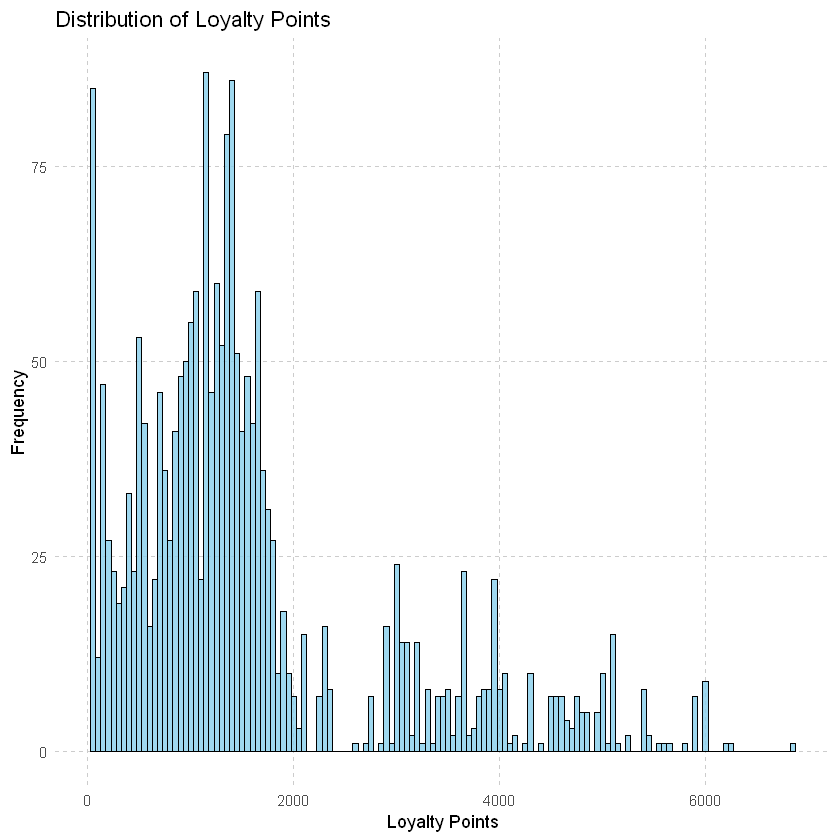

In [8]:
# 3a. Create Visualizations
# 3ai. Histogram of Loyalty Points (Distribution)
ggplot(data, aes(x = loyalty_points)) +
  geom_histogram(binwidth = 50, fill = "skyblue", color = "black", alpha = 0.8) +
  labs(title = "Distribution of Loyalty Points", x = "Loyalty Points", y = "Frequency") +
  theme_minimal() +
  theme(
    panel.grid.major = element_line(linetype = "dashed", color = "grey80"),
    panel.grid.minor = element_blank()
  )

# Export the plot
ggsave("loyalty_histogram.png", width = 8, height = 5, dpi = 300)

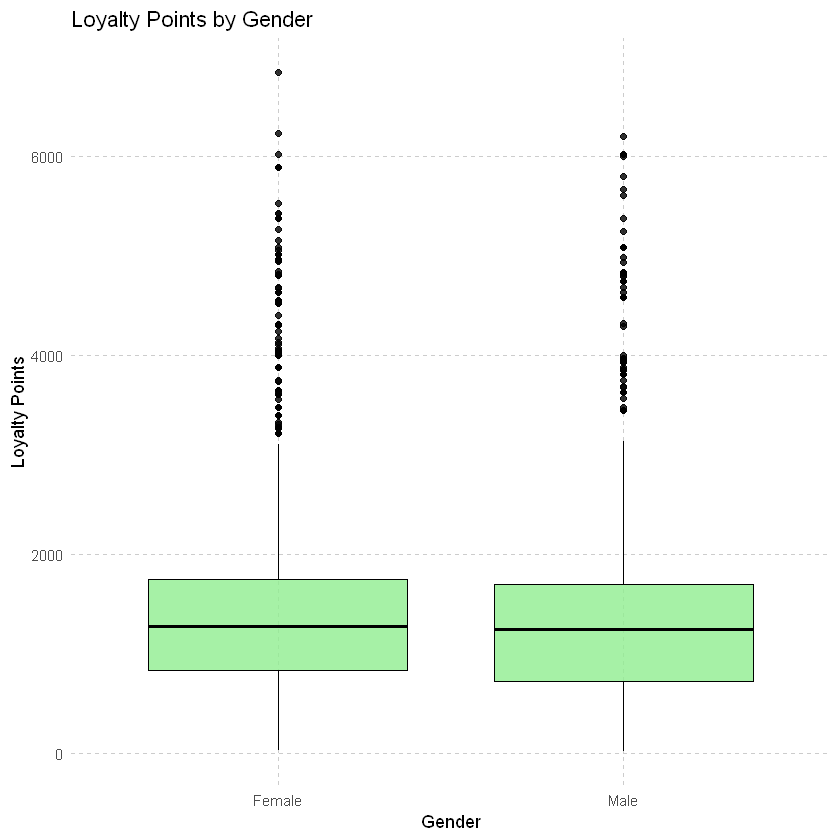

In [10]:
# 3aii. Boxplot of Loyalty Points by Gender
ggplot(data, aes(x = gender, y = loyalty_points)) +
  geom_boxplot(fill = "lightgreen", color = "black", alpha = 0.8) +
  labs(title = "Loyalty Points by Gender", x = "Gender", y = "Loyalty Points") +
  theme_minimal() +
  theme(
    panel.grid.major = element_line(linetype = "dashed", color = "grey80"),
    panel.grid.minor = element_blank()
  )

# Export the plot
ggsave("loyalty_vs_gender_boxplot.png", width = 8, height = 5, dpi = 300)

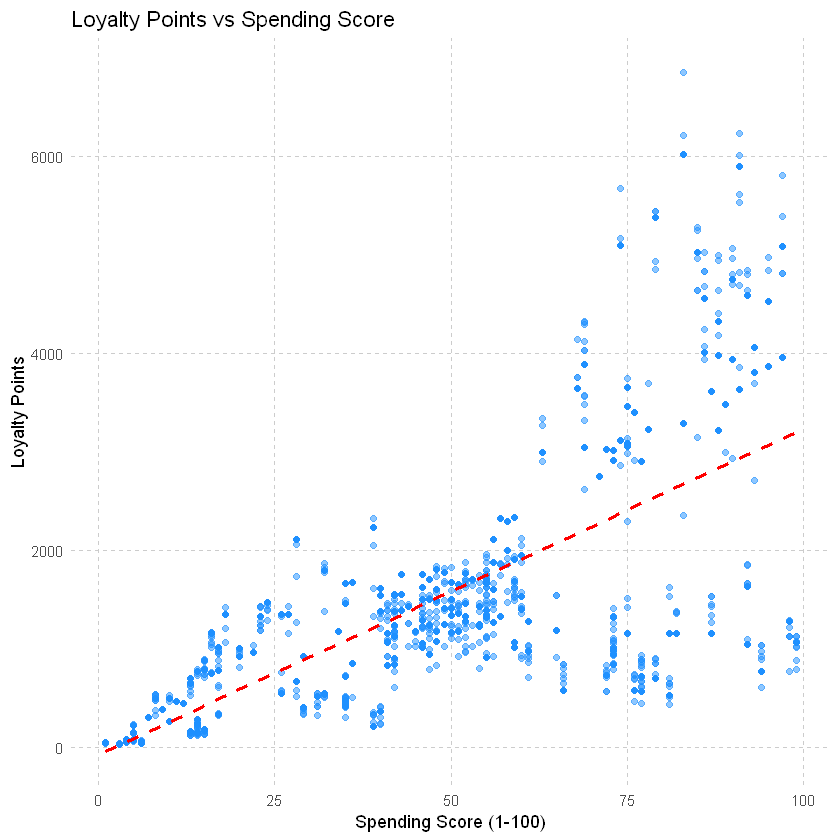

In [12]:
# 3aiii. Scatterplot of Loyalty Points vs Spending Score
ggplot(data, aes(x = spending_score, y = loyalty_points)) +
  geom_point(alpha = 0.5, color = "dodgerblue") +
  geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") +
  labs(title = "Loyalty Points vs Spending Score", x = "Spending Score (1-100)", y = "Loyalty Points") +
  theme_minimal() +
  theme(
    panel.grid.major = element_line(linetype = "dashed", color = "grey80"),
    panel.grid.minor = element_blank()
  )

# Export the plot
ggsave("loyalty_vs_spending_score_scatter.png", width = 8, height = 5, dpi = 300)

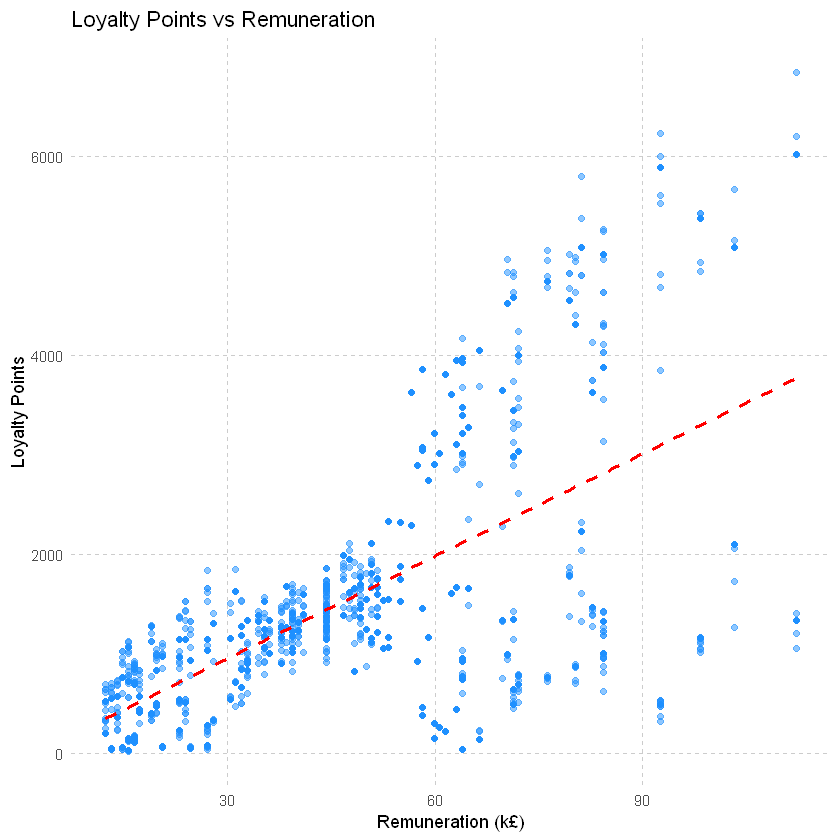

In [14]:
# 3aiv. Scatterplot of Loyalty Points vs Remuneration
ggplot(data, aes(x = remuneration, y = loyalty_points)) +
  geom_point(alpha = 0.5, color = "dodgerblue") +
  geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") +
  labs(title = "Loyalty Points vs Remuneration", x = "Remuneration (k£)", y = "Loyalty Points") +
  theme_minimal() +
  theme(
    panel.grid.major = element_line(linetype = "dashed", color = "grey80"),
    panel.grid.minor = element_blank()
  )

# Export the plot
ggsave("loyalty_vs_remuneration_scatter.png", width = 8, height = 5, dpi = 300)

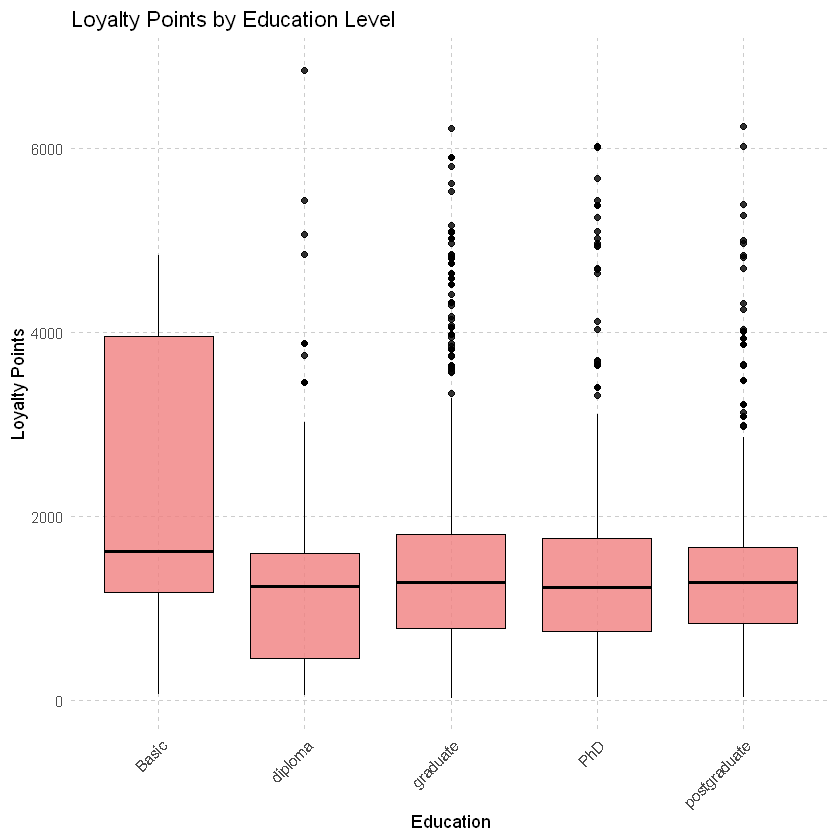

In [16]:
# 3bii. Additional Visualization: Boxplot by Education Level
ggplot(data, aes(x = education, y = loyalty_points)) +
  geom_boxplot(fill = "lightcoral", color = "black", alpha = 0.8) +
  labs(title = "Loyalty Points by Education Level", x = "Education", y = "Loyalty Points") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major = element_line(linetype = "dashed", color = "grey80"),
    panel.grid.minor = element_blank()
  )

# Export the plot
ggsave("loyalty_vs_education_boxplot.png", width = 8, height = 5, dpi = 300)

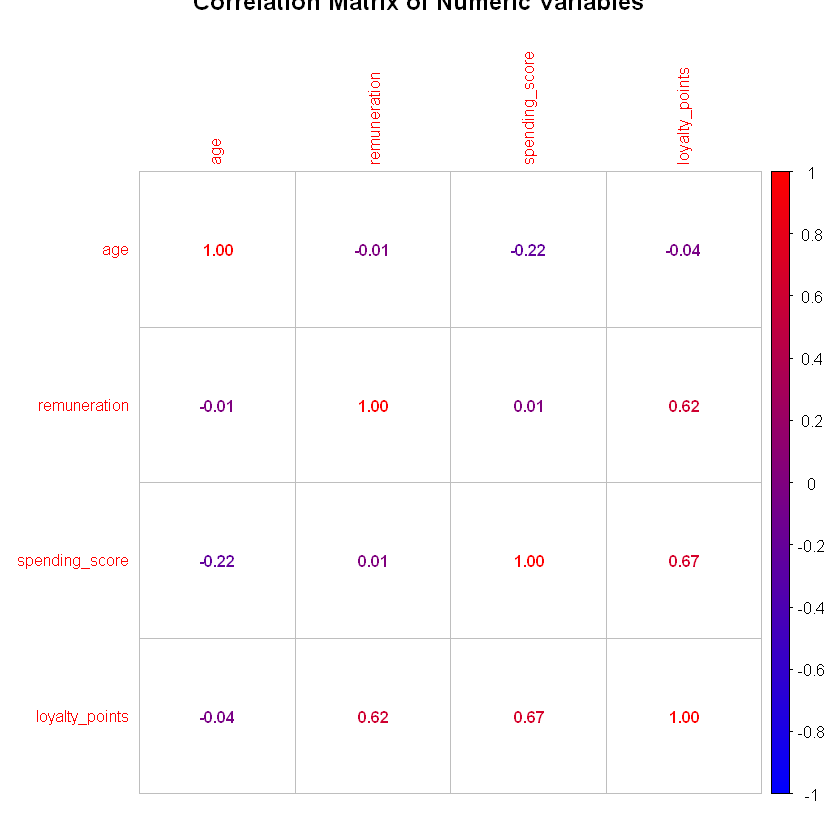

In [18]:
# 3c. Correlation Matrix for Numeric Variables
numeric_data <- data %>% select_if(is.numeric)  # Precompute for efficiency
correlation_matrix <- cor(numeric_data, use = "complete.obs")

# Plot correlation matrix with numbers and blue-red color
par(mar = c(1, 1, 2, 1))  # Adjust margins to prevent title cutoff
corrplot(correlation_matrix, 
         method = "number", 
         title = "Correlation Matrix of Numeric Variables", 
         col = colorRampPalette(c("blue", "red"))(200), 
         number.cex = 0.8,  # Adjust number size
         tl.cex = 0.8)      # Adjust label size

In [20]:
# 3a. Descriptive Statistics for Loyalty Points
loyalty_stats <- data %>%
  summarise(
    Mean = mean(loyalty_points, na.rm = TRUE),
    Median = median(loyalty_points, na.rm = TRUE),
    SD = sd(loyalty_points, na.rm = TRUE),
    Skewness = skewness(loyalty_points, na.rm = TRUE),
    Kurtosis = kurtosis(loyalty_points, na.rm = TRUE),
    Min = min(loyalty_points, na.rm = TRUE),
    Max = max(loyalty_points, na.rm = TRUE)
  )
print("Loyalty Points Descriptive Statistics:")
print(loyalty_stats)

[1] "Loyalty Points Descriptive Statistics:"
# A tibble: 1 x 7
   Mean Median    SD Skewness Kurtosis   Min   Max
  <dbl>  <dbl> <dbl>    <dbl>    <dbl> <dbl> <dbl>
1 1578.   1276 1283.     1.46     4.71    25  6847


In [22]:
# 3b. Descriptive Statistics for Numeric Variables
numeric_stats <- numeric_data %>%
  summarise_all(list(
    mean = ~mean(., na.rm = TRUE),
    sd = ~sd(., na.rm = TRUE)
  ))
print("Numeric Variables Descriptive Statistics:")
print(numeric_stats)

[1] "Numeric Variables Descriptive Statistics:"
# A tibble: 1 x 8
  age_mean remuneration_me~ spending_score_~ loyalty_points_~ age_sd
     <dbl>            <dbl>            <dbl>            <dbl>  <dbl>
1     39.5             48.1               50            1578.   13.6
# ... with 3 more variables: remuneration_sd <dbl>, spending_score_sd <dbl>,
#   loyalty_points_sd <dbl>


In [24]:
# 4a. Define VIF Function for Multicollinearity Check
vif_manual <- function(model, data) {
  vif_vals <- NULL
  vars <- names(coef(model))[-1]  # Remove intercept
  for (var in vars) {
    clean_vars <- vars[vars != var]
    fmla <- as.formula(paste(var, "~", paste(clean_vars, collapse = " + ")))
    r2 <- summary(lm(fmla, data = data))$r.squared
    vif_vals[var] <- 1 / (1 - r2)
  }
  return(vif_vals)
}
# Note: VIF > 5 indicates high multicollinearity; consider removing predictors if necessary.

In [26]:
# 4b. Linear Regression Model
model <- lm(loyalty_points ~ age + remuneration + spending_score, data = data)

# Check multicollinearity using VIF
print("VIF Values (Check for Multicollinearity):")
vif_values <- vif_manual(model, data)
print(vif_values)
if (any(vif_values > 5)) {
  print("Warning: High multicollinearity detected (VIF > 5). Consider removing predictors.")
}

# Model summary
print("Linear Regression Summary:")
summary(model)

[1] "VIF Values (Check for Multicollinearity):"
           age   remuneration spending_score 
      1.053015       1.000052       1.053014 
[1] "Linear Regression Summary:"



Call:
lm(formula = loyalty_points ~ age + remuneration + spending_score, 
    data = data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1819.11  -350.84     4.61   291.00  1894.62 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -2203.0598    52.3609  -42.08   <2e-16 ***
age               11.0607     0.8688   12.73   <2e-16 ***
remuneration      34.0084     0.4970   68.43   <2e-16 ***
spending_score    34.1832     0.4519   75.64   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 513.8 on 1996 degrees of freedom
Multiple R-squared:  0.8399,	Adjusted R-squared:  0.8397 
F-statistic:  3491 on 3 and 1996 DF,  p-value: < 2.2e-16


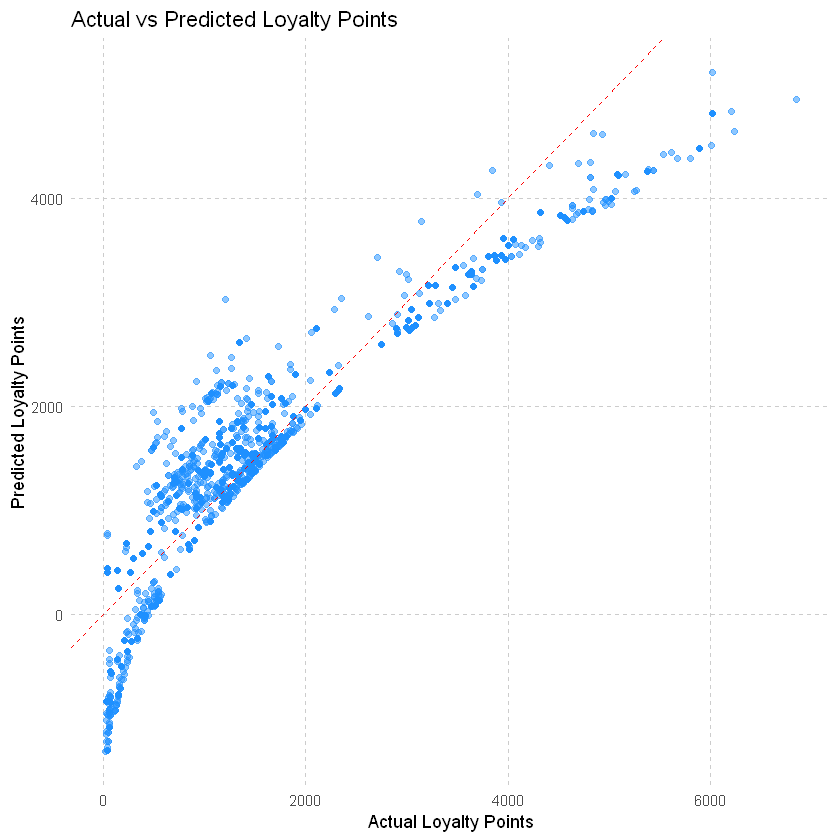

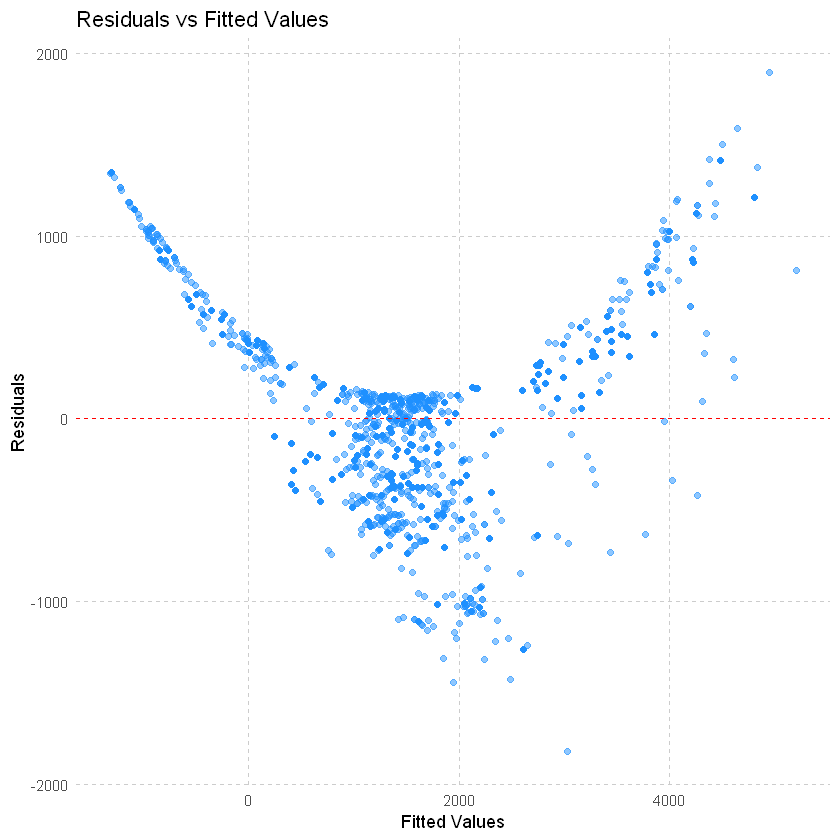

In [28]:
# 4c. Model Diagnostics
# Actual vs Predicted Plot
ggplot(data, aes(x = loyalty_points, y = predict(model, data))) +
  geom_point(alpha = 0.5, color = "dodgerblue") +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Actual vs Predicted Loyalty Points", x = "Actual Loyalty Points", y = "Predicted Loyalty Points") +
  theme_minimal() +
  theme(
    panel.grid.major = element_line(linetype = "dashed", color = "grey80"),
    panel.grid.minor = element_blank()
  )

# Export the plot
ggsave("actual_vs_predicted_loyalty.png", width = 8, height = 5, dpi = 300)

# Additional Diagnostic: Residuals vs Fitted Plot
ggplot(data.frame(Fitted = fitted(model), Residuals = resid(model)), 
       aes(x = Fitted, y = Residuals)) +
  geom_point(alpha = 0.5, color = "dodgerblue") +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Residuals vs Fitted Values", x = "Fitted Values", y = "Residuals") +
  theme_minimal() +
  theme(
    panel.grid.major = element_line(linetype = "dashed", color = "grey80"),
    panel.grid.minor = element_blank()
  )

# Export the residuals plot
ggsave("residuals_vs_fitted_loyalty.png", width = 8, height = 5, dpi = 300)